**SEMANTIC CHUNKING EXPERIMENT**

Replaces the fixed-size `SentenceSplitter` with `SemanticSplitterNodeParser`, which
cuts where the meaning shifts instead of at a token count.

- Sentences are embedded in overlapping groups (`buffer_size`)
- Cosine **distance** (`1 - similarity`) is measured between consecutive groups
- A cut is made wherever the distance exceeds the `breakpoint_percentile_threshold`
  percentile *of that document's own distances*

Things this notebook is for: seeing where the cuts land, how big the chunks get,
and whether it beats the fixed-size baseline.


### 1. Setup

In [1]:
# import libraries

from llama_index.core import Document, SimpleDirectoryReader
from llama_index.core.node_parser import SemanticSplitterNodeParser, SentenceSplitter
from llama_index.core.node_parser.text.utils import split_by_sentence_tokenizer
from llama_index.readers.file import PyMuPDFReader
from pymilvus import DataType, MilvusClient

from researchlens.config import Settings
from researchlens.embeddings import get_embed_model
from researchlens.normalization import DataNormalizer

settings = Settings.load()
settings.embed_model, settings.embed_dim

('sentence-transformers/all-MiniLM-L6-v2', 384)

In [2]:
# the same cached BERT model the app uses - no second copy is loaded

embed_model = get_embed_model(settings)
len(embed_model.get_query_embedding("dimension probe"))

2026-09-18 11:03:52,792 - INFO - Starting background load of embedding model ('huggingface', 'sentence-transformers/all-MiniLM-L6-v2')
/home/nipuna/Documents/Personal/ininsight/ResearchLens/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-18 11:03:56,863 - INFO - Loading embedding model sentence-transformers/all-MiniLM-L6-v2 from the local HuggingFace cache
2026-09-18 11:03:56,865 - INFO - Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11326.15it/s]


384

In [3]:
# pick a paper

PDF = "../data/Analysis of the Effectiveness of ARIMA, SARIMA, and SVR.pdf"

reader = SimpleDirectoryReader(input_files=[PDF], file_extractor={".pdf": PyMuPDFReader()})
pages = reader.load_data()

print("pages:", len(pages))

pages: 18


### 2. Normalization

Same `DataNormalizer` the app uses: NFKC, hyphenation repair, newline and whitespace collapsing.

In [4]:
# normalize (mutates in place, so reload above if you want the raw text back)

pages = DataNormalizer(documents=pages).normalize()

print(repr(pages[12].text[:300]))

'Energies 2024, 17, 4803 13 of 18 Table 5. Comparison of actual energy production values by the Ł ̨eki Dukielskie wind farms with predictions made using ARIMA (test 1, test 2), SARIMA, and SVR methods (GWh). Month Actual Values ARIMA Test 1 ARIMA Test 2 SARIMA SVR 03.2021 0.248 0.363 0.398 0.365 0.36'


### 3. Per page, or whole document?

`PyMuPDFReader` returns **one Document per page**. Splitting page by page means a
topic spanning a page break is always cut there, and the percentile is computed
over very few distances. Build both so they can be compared.

In [5]:
# variant A: one document per page (what the app does today)

per_page = pages
print("documents:", len(per_page))

documents: 18


In [6]:
# variant B: the whole paper as one document, page numbers recorded as offsets

page_offsets = []   # (char_start, page_number)
buffer = []
cursor = 0
for page in pages:
    page_offsets.append((cursor, int(page.metadata["source"])))
    buffer.append(page.text)
    cursor += len(page.text) + 1

whole = Document(text="\n".join(buffer), metadata={"file_name": pages[0].metadata["file_name"]})
print("chars:", len(whole.text), "| pages mapped:", len(page_offsets))

chars: 52120 | pages mapped: 18


In [7]:
# map a character offset back to a page number

def page_for_offset(offset: int) -> int:
    page = page_offsets[0][1]
    for start, number in page_offsets:
        if start > offset:
            break
        page = number
    return page

page_for_offset(0), page_for_offset(len(whole.text) // 2)

(1, 9)

### 4. What the sentence tokenizer sees

The splitter can never cut *inside* a sentence, so sentence quality is the ceiling on chunk quality.

In [8]:
# the exact tokenizer SemanticSplitterNodeParser uses by default

tokenize = split_by_sentence_tokenizer()

sentences = tokenize(pages[12].text)
print("sentences on page 13:", len(sentences))
for s in sentences[:5]:
    print(f"[{len(s):5d}] {s[:100]!r}")

sentences on page 13: 14
[   42] 'Energies 2024, 17, 4803 13 of 18 Table 5. '
[  165] 'Comparison of actual energy production values by the Ł ̨eki Dukielskie wind farms with predictions m'
[  781] 'Month Actual Values ARIMA Test 1 ARIMA Test 2 SARIMA SVR 03.2021 0.248 0.363 0.398 0.365 0.367 04.20'
[    5] '3.5. '
[  124] 'Error Values Error values for each method using parameters that resulted in the lowest MAPE error ar'


In [9]:
# sentence length distribution over the whole paper - long ones become atomic chunks

all_sentences = tokenize(whole.text)
lengths = sorted(len(s) for s in all_sentences)

print("sentences:", len(all_sentences))
print("median:", lengths[len(lengths) // 2], "| p90:", lengths[int(len(lengths) * 0.9)], "| max:", lengths[-1])
print()
print("longest:", repr(max(all_sentences, key=len)[:200]))

sentences: 520
median: 93 | p90: 203 | max: 781

longest: 'Month Actual Values ARIMA Test 1 ARIMA Test 2 SARIMA SVR 03.2021 0.248 0.363 0.398 0.365 0.367 04.2021 0.318 0.281 0.260 0.285 0.286 05.2021 0.410 0.194 0.199 0.237 0.270 06.2021 0.123 0.182 0.176 0.1'


### 5. Header and footer noise

Running headers get glued onto the first real sentence of every page. They are semantically unlike their neighbours, so they compete for the limited number of cuts.

In [10]:
# first 60 characters of each page - repeated boilerplate shows up immediately

for page in pages[:6]:
    print(f"p{page.metadata['source']:>2}: {page.text[:60]!r}")

p 1: 'Citation: Szostek, K.; Mazur, D.; Drałus, G.; Kusznier, J. A'
p 2: 'Energies 2024, 17, 4803 2 of 18 conditions, to predict the f'
p 3: 'Energies 2024, 17, 4803 3 of 18 Conversely, reference [19] p'
p 4: 'Energies 2024, 17, 4803 4 of 18 Figure 1. Electricity produc'
p 5: 'Energies 2024, 17, 4803 5 of 18 that decomposes time series '
p 6: 'Energies 2024, 17, 4803 6 of 18 patterns in the data. The re'


### 6. Semantic splitting

In [11]:
# the splitter - lower the threshold for more, smaller chunks

splitter = SemanticSplitterNodeParser(
    embed_model=embed_model,
    buffer_size=1,
    breakpoint_percentile_threshold=95,
)

In [28]:
# run it on the whole document
semantic_nodes = splitter.build_semantic_nodes_from_documents([whole], show_progress=False)
print("chunks:", len(semantic_nodes))

chunks: 27


In [13]:
# chunk size distribution - semantic chunks have no upper bound

sizes = sorted(len(n.text) for n in semantic_nodes)

print("min:", sizes[0], "| median:", sizes[len(sizes) // 2], "| max:", sizes[-1])
print("over 10000 bytes (the Milvus VARCHAR limit):",
      sum(1 for n in semantic_nodes if len(n.text.encode("utf-8")) > 10_000))

min: 13 | median: 257 | max: 36087
over 10000 bytes (the Milvus VARCHAR limit): 1


In [14]:
# read a few chunks and judge the cuts by eye

for node in semantic_nodes[:3]:
    print(f"--- {len(node.text)} chars ---")
    print(node.text[:400])
    print()

--- 428 chars ---
Citation: Szostek, K.; Mazur, D.; Drałus, G.; Kusznier, J. Analysis of the Effectiveness of ARIMA, SARIMA, and SVR Models in Time Series Forecasting: A Case Study of Wind Farm Energy Production. Energies 2024, 17, 4803. https://doi.org/ 10.3390/en17194803 Academic Editor: John Boland Received: 12 August 2024 Revised: 17 September 2024 Accepted: 20 September 2024 Published: 25 September 2024 Copyri

--- 36087 chars ---
Licensee MDPI, Basel, Switzerland. This article is an open access article distributed under the terms and conditions of the Creative Commons Attribution (CC BY) license (https:// creativecommons.org/licenses/by/ 4.0/). energies Article Analysis of the Effectiveness of ARIMA, SARIMA, and SVR Models in Time Series Forecasting: A Case Study of Wind Farm Energy Production Kamil Szostek 1 , Damian Mazu

--- 8273 chars ---
Error Values Error values for each method using parameters that resulted in the lowest MAPE error are presented in Table 6. Table 6. Error 

### 7. Where the cuts came from

Reproduces the splitter's internals so the distance curve and the threshold are visible.

In [ ]:
# rebuild the sentence groups and embed them

text_splits = splitter.sentence_splitter(whole.text)
groups = splitter._build_sentence_groups(text_splits)

embeddings = embed_model.get_text_embedding_batch([g["combined_sentence"] for g in groups], show_progress=False)
for i, embedding in enumerate(embeddings):
    groups[i]["combined_sentence_embedding"] = embedding

len(groups)

CPU times: user 1min 2s, sys: 337 ms, total: 1min 2s
Wall time: 8.24 s


520

In [16]:
# cosine distance between consecutive groups

import numpy as np

distances = splitter._calculate_distances_between_sentence_groups(groups)
threshold = np.percentile(distances, splitter.breakpoint_percentile_threshold)

print("distances:", len(distances))
print("threshold:", round(float(threshold), 4))
print("cuts:", sum(1 for d in distances if d > threshold))

distances: 519
threshold: 0.7864
cuts: 26


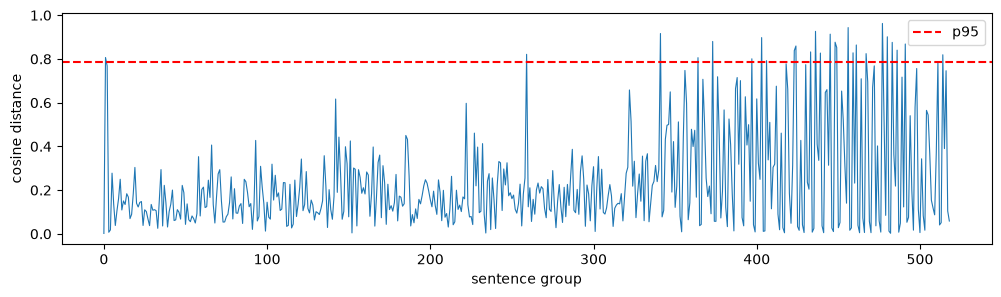

In [17]:
# plot the distance curve with the cut line

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(distances, linewidth=0.8)
ax.axhline(threshold, color="red", linestyle="--", label=f"p{splitter.breakpoint_percentile_threshold}")
ax.set_xlabel("sentence group")
ax.set_ylabel("cosine distance")
ax.legend()
plt.show()

In [18]:
# the sentences on either side of each cut - are these real topic shifts?

cuts = [i for i, d in enumerate(distances) if d > threshold]

for i in cuts[:5]:
    print(f"distance {distances[i]:.4f}")
    print("  before:", text_splits[i][-90:].strip())
    print("   after:", text_splits[i + 1][:90].strip())
    print()

distance 0.8066
  before: ccepted: 20 September 2024 Published: 25 September 2024 Copyright: © 2024 by the authors.
   after: Licensee MDPI, Basel, Switzerland.

distance 0.8212
  before: 3.5.
   after: Error Values Error values for each method using parameters that resulted in the lowest MAP

distance 0.9164
  before: ; project administration, J.K.
   after: All authors have read and agreed to the published version of the manuscript.

distance 0.8058
  before: ; Hossain, S.; Mofijur, M.; Kabir, Z.; Badruddin, I.A.
   after: ; Yunus Khan, T.M.

distance 0.8800
  before: ; Mannan, M.; Mansor, M.; Al-Masri, H.M.K.
   after: ; Mahlia, T.M.I.



### 8. Threshold sweep

How the percentile trades chunk count against chunk size.

In [19]:
# sweep the threshold - reuses the embeddings above, so this is fast

for percentile in (80, 85, 90, 95, 99):
    cut_at = np.percentile(distances, percentile)
    chunks = splitter._build_node_chunks(groups, distances) if percentile == 95 else None
    n_cuts = sum(1 for d in distances if d > cut_at)
    print(f"p{percentile}: threshold={cut_at:.4f}  cuts={n_cuts}  ~chunks={n_cuts + 1}")

p80: threshold=0.3543  cuts=104  ~chunks=105
p85: threshold=0.4336  cuts=78  ~chunks=79
p90: threshold=0.6168  cuts=52  ~chunks=53
p95: threshold=0.7864  cuts=26  ~chunks=27
p99: threshold=0.9006  cuts=6  ~chunks=7


### 9. Baseline comparison

In [20]:
# the fixed-size splitter the app uses today

baseline = SentenceSplitter(chunk_size=settings.chunk_size, chunk_overlap=settings.chunk_overlap)
baseline_nodes = baseline.get_nodes_from_documents([whole])

baseline_sizes = sorted(len(n.text) for n in baseline_nodes)
print("sentence splitter :", len(baseline_nodes), "chunks | median", baseline_sizes[len(baseline_sizes) // 2], "| max", baseline_sizes[-1])
print("semantic splitter :", len(semantic_nodes), "chunks | median", sizes[len(sizes) // 2], "| max", sizes[-1])

sentence splitter : 15 chunks | median 4334 | max 5262
semantic splitter : 27 chunks | median 257 | max 36087


### 10. Load into Milvus

A separate collection, so the existing one stays intact and the two can be queried side by side.

In [21]:
# split anything too large for the VARCHAR field, then embed

MAX_BYTES = 10_000

safe_nodes = []
for node in semantic_nodes:
    if len(node.text.encode("utf-8")) <= MAX_BYTES:
        safe_nodes.append(node)
    else:
        safe_nodes.extend(baseline.get_nodes_from_documents([Document(text=node.text)]))

print("chunks after size fallback:", len(safe_nodes))

chunks after size fallback: 35


In [ ]:
# embed the chunks

texts = [n.text for n in safe_nodes]
vectors = embed_model.get_text_embedding_batch(texts, show_progress=False)

len(vectors), len(vectors[0])

CPU times: user 7.92 s, sys: 130 ms, total: 8.05 s
Wall time: 1.05 s


(35, 384)

In [23]:
# connect

collection_name = "paper_chunks_semantic"

client = MilvusClient(uri=settings.milvus_uri, token=settings.milvus_token)
client.list_collections()

['thesis_source']

In [24]:
# schema - identical to the app's, so the CLI can read this collection

if client.has_collection(collection_name):
    client.drop_collection(collection_name)

schema = client.create_schema(auto_id=False, enable_dynamic_field=False)
schema.add_field("id", DataType.VARCHAR, max_length=100, is_primary=True)
schema.add_field("title", DataType.VARCHAR, max_length=500)
schema.add_field("page", DataType.INT64)
schema.add_field("chunk_index", DataType.INT64)
schema.add_field("text", DataType.VARCHAR, max_length=MAX_BYTES)
schema.add_field("embedding", DataType.FLOAT_VECTOR, dim=settings.embed_dim)

index_params = client.prepare_index_params()
index_params.add_index(field_name="embedding", index_type="AUTOINDEX", metric_type="COSINE")

client.create_collection(collection_name=collection_name, schema=schema, index_params=index_params)
client.has_collection(collection_name)

True

In [25]:
# insert

title = "Analysis of the Effectiveness of ARIMA, SARIMA, and SVR"
offset = 0
rows = []
for index, (node, vector) in enumerate(zip(safe_nodes, vectors)):
    start = whole.text.find(node.text[:80], offset)
    if start >= 0:
        offset = start
    rows.append({
        "id": node.id_,
        "title": title,
        "page": page_for_offset(offset),
        "chunk_index": index,
        "text": node.text,
        "embedding": vector,
    })

client.insert(collection_name=collection_name, data=rows)

# Freshly inserted rows sit in an unsealed segment: flush makes them
# searchable, load brings the collection into memory. Without both, the
# queries below come back empty even though the rows are there.
client.flush(collection_name)
client.load_collection(collection_name)

client.query(collection_name=collection_name, filter="", output_fields=["count(*)"])

data: ["{'count(*)': 35}"], extra_info: {}

### 11. Query it

In [26]:
# semantic search against the semantic-chunked collection

query = "How accurate is SARIMA compared to ARIMA for wind farm energy forecasting?"

hits = client.search(
    collection_name=collection_name,
    data=[embed_model.get_query_embedding(query)],
    limit=5,
    output_fields=["page", "chunk_index", "text"],
)

for hit in hits[0]:
    print(f"score {hit['distance']:.4f} | page {hit['entity']['page']} | {len(hit['entity']['text'])} chars")
    print(" ", hit["entity"]["text"][:180].replace("\n", " "))
    print()

score 0.7504 | page 1 | 428 chars
  Citation: Szostek, K.; Mazur, D.; Drałus, G.; Kusznier, J. Analysis of the Effectiveness of ARIMA, SARIMA, and SVR Models in Time Series Forecasting: A Case Study of Wind Farm Ener

score 0.6849 | page 1 | 4707 chars
  Licensee MDPI, Basel, Switzerland. This article is an open access article distributed under the terms and conditions of the Creative Commons Attribution (CC BY) license (https:// c

score 0.6433 | page 12 | 2120 chars
  Monthly Forecasts The forecast results were monthly predictions made using three tested methods for each of the wind farms. For both ARIMA and SARIMA methods, tests were conducted 

score 0.6071 | page 2 | 5568 chars
  One branch of forecasting is autoregressive models, which are based on the assumption that future values of the dependent variable can be predicted based on its past values. These 

score 0.6009 | page 17 | 406 chars
  ; Belavagi, M.C.; Attigeri, G. Profit Prediction Using ARIMA, SARIMA and LSTM Models in

In [27]:
# same query through the cross-encoder the app uses, to see the final ordering

from researchlens import reranking
from researchlens.store import SearchHit

candidates = [
    SearchHit(score=h["distance"], title=title, page=h["entity"]["page"],
              chunk_index=h["entity"]["chunk_index"], text=h["entity"]["text"])
    for h in hits[0]
]

for hit in reranking.rerank(settings, query, candidates)[:3]:
    print(f"rerank {hit.rerank_score:+.3f} | vector {hit.score:.4f} | page {hit.page}")
    print(" ", hit.text[:180].replace("\n", " "))
    print()

2026-09-18 11:04:19,595 - INFO - Starting background load of reranker BAAI/bge-reranker-base
2026-09-18 11:04:19,597 - INFO - Loading reranker BAAI/bge-reranker-base from the local HuggingFace cache
2026-09-18 11:04:19,598 - INFO - No device provided, using cpu
2026-09-18 11:04:19,600 - INFO - No modules.json found for BAAI/bge-reranker-base, initializing a new CrossEncoder model.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8971.63it/s]
2026-09-18 11:04:23,903 - INFO - Reranked 5 candidates with BAAI/bge-reranker-base


rerank +0.999 | vector 0.6849 | page 1
  Licensee MDPI, Basel, Switzerland. This article is an open access article distributed under the terms and conditions of the Creative Commons Attribution (CC BY) license (https:// c

rerank +0.998 | vector 0.6071 | page 2
  One branch of forecasting is autoregressive models, which are based on the assumption that future values of the dependent variable can be predicted based on its past values. These 

rerank +0.996 | vector 0.6433 | page 12
  Monthly Forecasts The forecast results were monthly predictions made using three tested methods for each of the wind farms. For both ARIMA and SARIMA methods, tests were conducted 

